# Customer Churn Prediction

Goal: predict which telecom customers are likely to churn so the retention team can act early.

Dataset: IBM Telco Customer Churn — 7,043 customers, 21 columns, with `Churn` as the Yes/No target (26.5% churn).

Workflow: data preparation → EDA → feature engineering → model development → evaluation → interpretation → saved pipeline. The pipeline is served by `app.py` through `POST /predict`.

## 1. Data Understanding & Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('../data/TelcoCustomerChurn.csv')
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

`tenure` and `SeniorCitizen` are `int64`, `MonthlyCharges` is `float64`, and the remaining columns are stored as strings. `TotalCharges` needs to be converted to numeric.

In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal missing:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customerIDs:", df['customerID'].duplicated().sum())

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total missing: 0
Duplicate rows: 0
Duplicate customerIDs: 0


In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Now missing in TotalCharges:", df['TotalCharges'].isnull().sum())

df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

Now missing in TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [6]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print("Remaining missing:", df['TotalCharges'].isnull().sum())
print("Rows with tenure = 0:", (df['tenure'] == 0).sum())

Remaining missing: 0
Rows with tenure = 0: 11


The 11 `TotalCharges` blanks are all customers with `tenure = 0`, so no billing cycle has been completed yet. Setting these values to `0` is appropriate; mean/median imputation would create a value that was never charged. The rows are kept because new customers are a valid segment.

In [7]:
df_model = df.drop('customerID', axis=1)

target = 'Churn'

numerical = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

categorical = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]

# Guard: confirm nothing was missed or misspelled
assert set(numerical + categorical + [target]) == set(df_model.columns), \
    "Column lists do not match the dataframe"

print("Numerical:", len(numerical), numerical)
print("\nCategorical:", len(categorical), categorical)

Numerical: 4 ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical: 15 ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


`SeniorCitizen` is stored as 0/1, so it is treated as numerical here. For a Decision Tree, this gives the same split as one-hot encoding it.

In [8]:
print(df['Churn'].value_counts())
print()
print(df['Churn'].value_counts(normalize=True).round(4) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


The target is about 3:1 (`No` vs `Yes`). Predicting `No` for everyone would give 73.5% accuracy but catch no churners, so accuracy alone is not enough. `class_weight='balanced'` is therefore tested.

In [9]:
for col in categorical:
    print(f"{col}: {df[col].nunique()} -> {list(df[col].unique())}")

gender: 2 -> ['Female', 'Male']
Partner: 2 -> ['Yes', 'No']
Dependents: 2 -> ['No', 'Yes']
PhoneService: 2 -> ['No', 'Yes']
MultipleLines: 3 -> ['No phone service', 'No', 'Yes']
InternetService: 3 -> ['DSL', 'Fiber optic', 'No']
OnlineSecurity: 3 -> ['No', 'Yes', 'No internet service']
OnlineBackup: 3 -> ['Yes', 'No', 'No internet service']
DeviceProtection: 3 -> ['No', 'Yes', 'No internet service']
TechSupport: 3 -> ['No', 'Yes', 'No internet service']
StreamingTV: 3 -> ['No', 'Yes', 'No internet service']
StreamingMovies: 3 -> ['No', 'Yes', 'No internet service']
Contract: 3 -> ['Month-to-month', 'One year', 'Two year']
PaperlessBilling: 2 -> ['Yes', 'No']
PaymentMethod: 4 -> ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']


In [10]:
df[numerical].describe().round(2)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76,2279.73
std,0.37,24.56,30.09,2266.79
min,0.00,0.00,18.25,0.00
25%,0.00,9.00,35.50,398.55
50%,0.00,29.00,70.35,1394.55
75%,0.00,55.00,89.85,3786.60
max,1.00,72.00,118.75,8684.80


## 2. Exploratory Data Analysis

In [11]:
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.titlesize'] = 13

churn_palette = {'No': '#4C9F70', 'Yes': '#D1495B'}

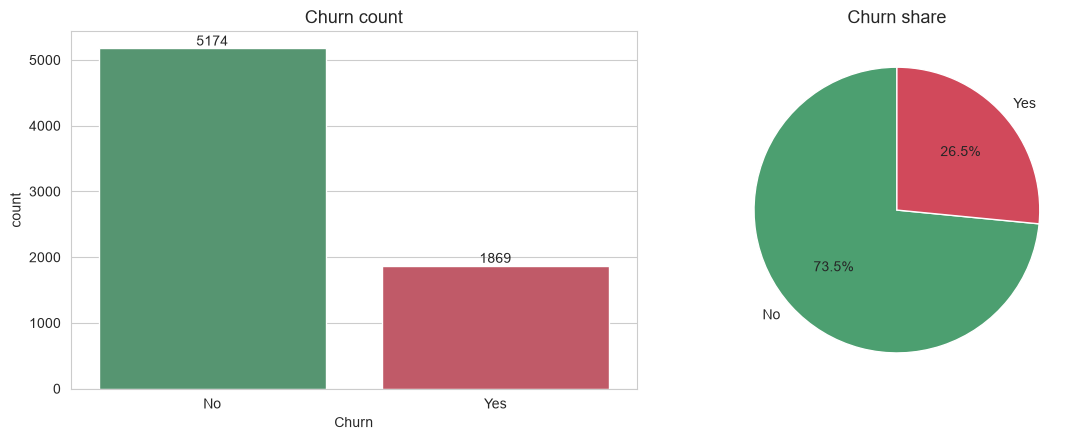

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

sns.countplot(data=df, x='Churn', hue='Churn', palette=churn_palette,
              legend=False, ax=ax[0])
ax[0].set_title('Churn count')
for c in ax[0].containers:
    ax[0].bar_label(c)

df['Churn'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#4C9F70', '#D1495B'],
                                     startangle=90, ax=ax[1], ylabel='')
ax[1].set_title('Churn share')

plt.tight_layout()
plt.show()

1,869 of 7,043 customers churned (26.5%). Since a 73.5% baseline is possible by always predicting `No`, the later model comparison focuses on recall, precision and F1 as well as accuracy.

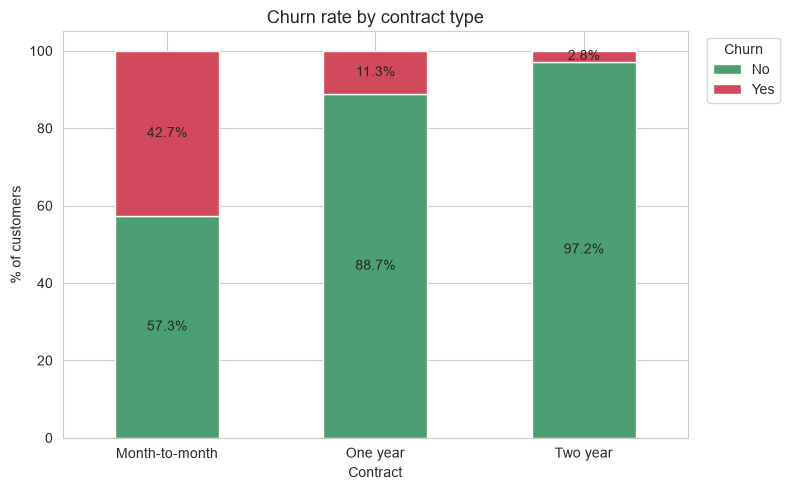

In [13]:
ct = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

ax = ct.plot(kind='bar', stacked=True, color=['#4C9F70', '#D1495B'],
             figsize=(8, 5), rot=0)
ax.set_title('Churn rate by contract type')
ax.set_ylabel('% of customers')
ax.legend(title='Churn', bbox_to_anchor=(1.02, 1))

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')

plt.tight_layout()
plt.show()

Contract type is the clearest signal: churn is 42.7% for month-to-month, 11.3% for one-year and 2.8% for two-year contracts.

This is association, not proof that the contract itself causes churn. Still, contract length is a strong segmentation for retention.

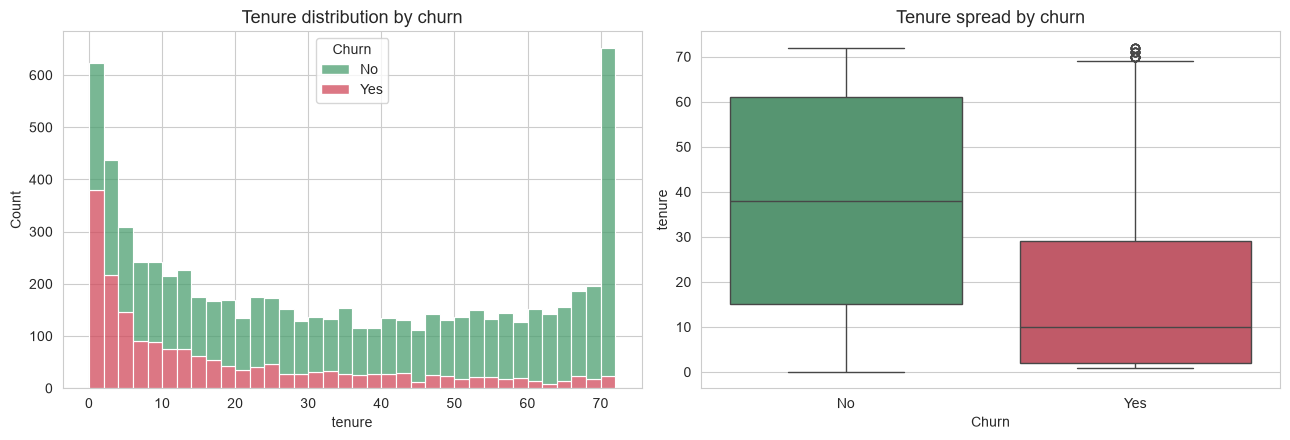

        count  mean   std  min   25%   50%   75%   max
Churn                                                 
No     5174.0  37.6  24.1  0.0  15.0  38.0  61.0  72.0
Yes    1869.0  18.0  19.5  1.0   2.0  10.0  29.0  72.0


In [14]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack',
             bins=36, palette=churn_palette, ax=ax[0])
ax[0].set_title('Tenure distribution by churn')

sns.boxplot(data=df, x='Churn', y='tenure', hue='Churn',
            palette=churn_palette, legend=False, ax=ax[1])
ax[1].set_title('Tenure spread by churn')

plt.tight_layout()
plt.show()

print(df.groupby('Churn')['tenure'].describe().round(1))

Churners have much shorter tenure: mean 18 months vs 37.6 for retained customers; median 10 vs 38 months.

Risk is concentrated in the early months, making onboarding and the first year important retention points.

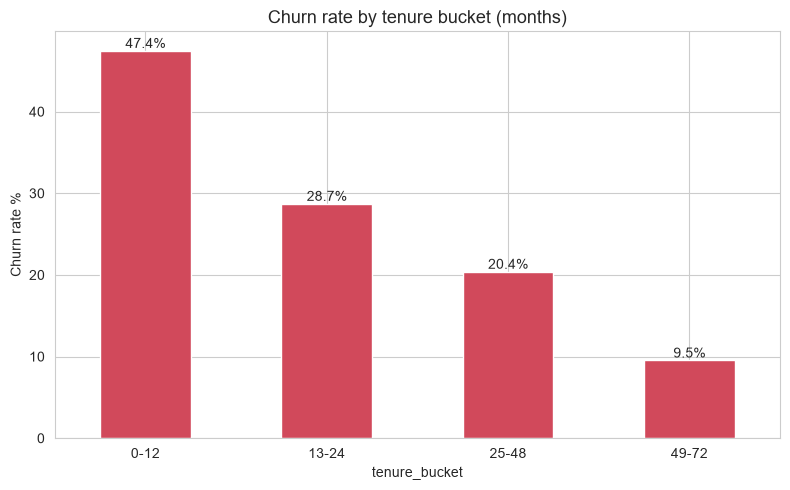

In [15]:
df['tenure_bucket'] = pd.cut(df['tenure'], bins=[-1, 12, 24, 48, 72],
                             labels=['0-12', '13-24', '25-48', '49-72'])

rate = pd.crosstab(df['tenure_bucket'], df['Churn'], normalize='index')['Yes'] * 100

ax = rate.plot(kind='bar', color='#D1495B', rot=0, figsize=(8, 5))
ax.set_title('Churn rate by tenure bucket (months)')
ax.set_ylabel('Churn rate %')
ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.tight_layout()
plt.show()

Churn falls steadily with tenure: 47.4% → 28.7% → 20.4% → 9.5%. Almost half of first-year customers churn, so these bands are useful for feature engineering.

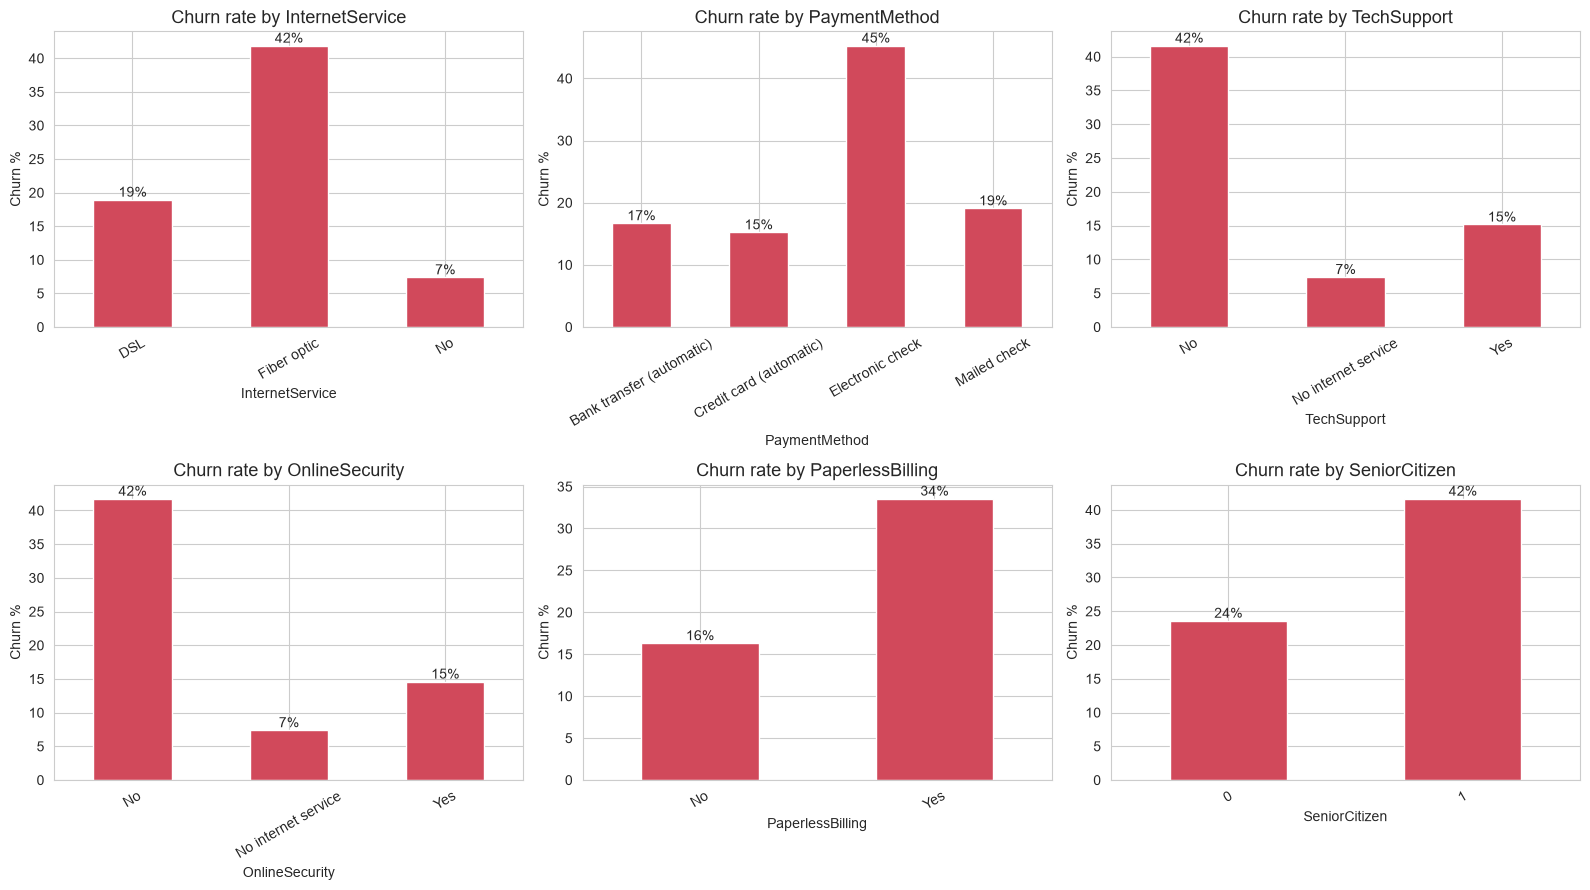

In [16]:
cols = ['InternetService', 'PaymentMethod', 'TechSupport',
        'OnlineSecurity', 'PaperlessBilling', 'SeniorCitizen']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for col, axis in zip(cols, axes.flatten()):
    r = pd.crosstab(df[col], df['Churn'], normalize='index')['Yes'] * 100
    r.plot(kind='bar', ax=axis, color='#D1495B', rot=30)
    axis.set_title(f'Churn rate by {col}')
    axis.set_ylabel('Churn %')
    axis.bar_label(axis.containers[0], fmt='%.0f%%')

plt.tight_layout()
plt.show()

Key category differences:

- Fiber optic: 41.9% churn vs 19.0% DSL and 7.4% with no internet.
- Electronic check: 45.3% churn vs 16.7% and 15.2% for the two automatic methods.
- No tech support: 41.6% vs 15.2% with support.
- No online security: 41.8% vs 14.6% with security.
- Senior citizens: 41.7% vs 23.6%.
- Paperless billing: 33.6% vs 16.3%.

These are useful associations to carry into modelling; they do not by themselves establish causation.

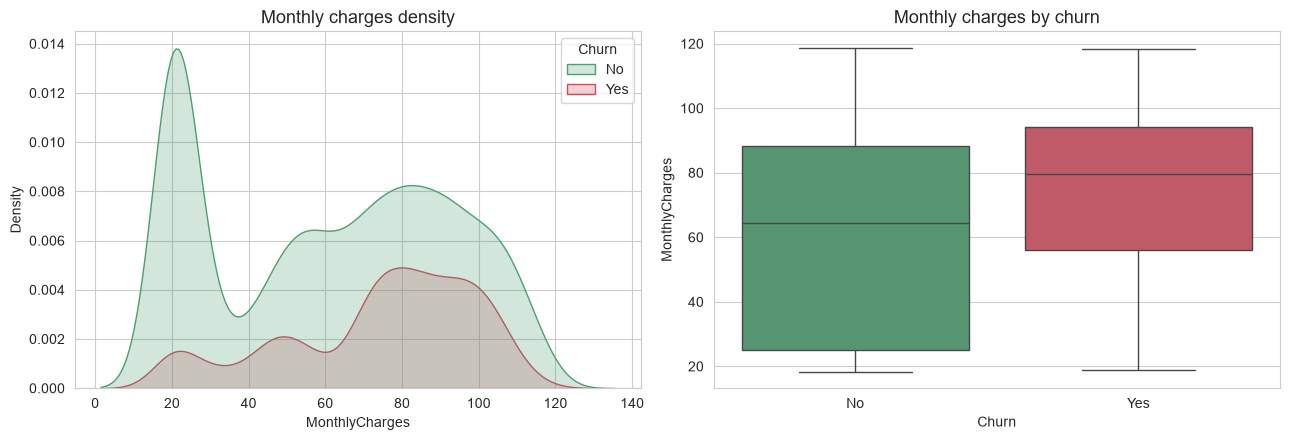

       MonthlyCharges  TotalCharges
Churn                              
No              61.27       2549.91
Yes             74.44       1531.80


In [17]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True,
            palette=churn_palette, ax=ax[0])
ax[0].set_title('Monthly charges density')

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn',
            palette=churn_palette, legend=False, ax=ax[1])
ax[1].set_title('Monthly charges by churn')

plt.tight_layout()
plt.show()

print(df.groupby('Churn')[['MonthlyCharges', 'TotalCharges']].mean().round(2))

Churners pay more monthly on average: 74.44 vs 61.27. Total charges are lower for churners (1531.80 vs 2549.91), mainly because they leave earlier.

So `MonthlyCharges` and `TotalCharges` capture different information. The combination of high monthly cost and short tenure looks especially risky.

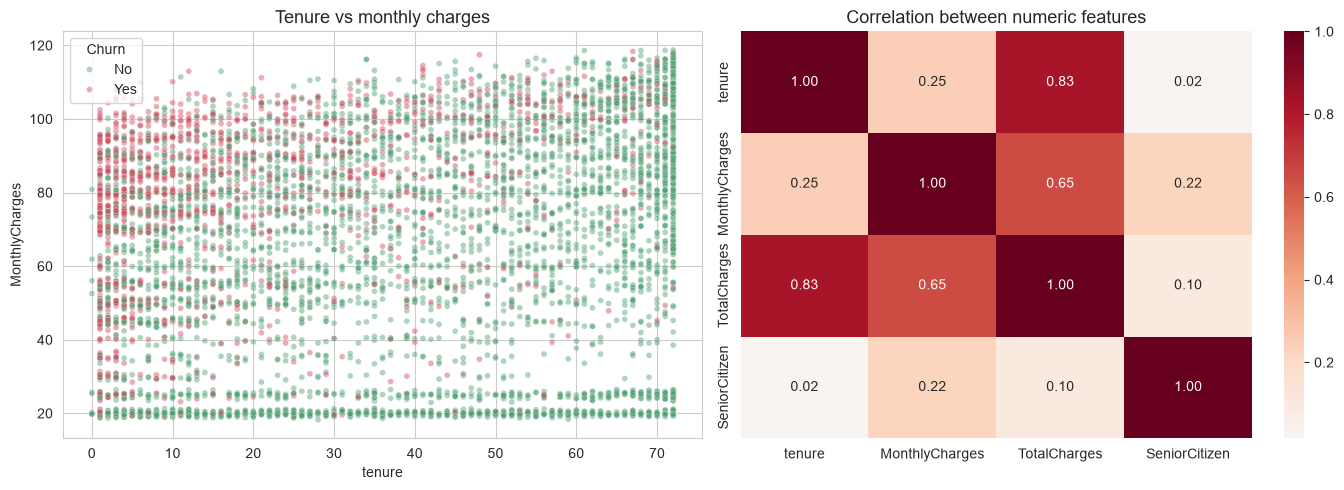

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn',
                palette=churn_palette, alpha=0.45, s=18, ax=ax[0])
ax[0].set_title('Tenure vs monthly charges')

corr = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']].corr()
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f', ax=ax[1])
ax[1].set_title('Correlation between numeric features')

plt.tight_layout()
plt.show()

The scatter shows churn concentrated around short tenure and higher monthly charges.

`tenure` and `TotalCharges` correlate at 0.83, which is expected because total charges depend strongly on tenure. Both are kept because a Decision Tree can use them separately.

In [19]:
df = df.drop('tenure_bucket', axis=1, errors='ignore')
print(df.shape)

(7043, 21)


Main EDA signals: month-to-month contracts, short tenure, fiber optic service, electronic check, lack of tech support/security, and higher monthly charges.

Gender is almost neutral: 26.9% churn for males vs 26.2% for females.

## 3. Feature Engineering

In [20]:
df['TenureBucket'] = pd.cut(
    df['tenure'],
    bins=[-1, 12, 24, 48, 72],
    labels=['0-12', '13-24', '25-48', '49-72']
).astype(str)

print(pd.crosstab(df['TenureBucket'], df['Churn'], normalize='index').round(3) * 100)

Churn           No   Yes
TenureBucket            
0-12          52.6  47.4
13-24         71.3  28.7
25-48         79.6  20.4
49-72         90.5   9.5


`TenureBucket`: tenure grouped into 0–12, 13–24, 25–48 and 49–72 months.

These fixed contract-style boundaries match the EDA pattern (47.4% → 28.7% → 20.4% → 9.5%) and make the result easier to explain. The cut points are fixed, not learned from the dataset.

In [21]:
addons = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
          'TechSupport', 'StreamingTV', 'StreamingMovies']

df['NumAddOnServices'] = (df[addons] == 'Yes').sum(axis=1)

print(df['NumAddOnServices'].value_counts().sort_index())
print()
print((pd.crosstab(df['NumAddOnServices'], df['Churn'], normalize='index')['Yes'] * 100).round(1))

NumAddOnServices
0    2219
1     966
2    1033
3    1118
4     852
5     571
6     284
Name: count, dtype: int64

NumAddOnServices
0    21.4
1    45.8
2    35.8
3    27.4
4    22.3
5    12.4
6     5.3
Name: Yes, dtype: float64


`NumAddOnServices`: count of the six optional add-ons, from 0 to 6.

The individual add-ons show related churn patterns, so the count gives the model one simple measure of product engagement. Churn is 21.4% at 0 add-ons, rises to 45.8% at 1, then falls to 5.3% at 6. The zero group is affected by customers with no internet service.

In [22]:
df['HasAutoPayment'] = df['PaymentMethod'].str.contains('automatic').astype(int)

print((pd.crosstab(df['HasAutoPayment'], df['Churn'], normalize='index')['Yes'] * 100).round(1))

HasAutoPayment
0    34.7
1    16.0
Name: Yes, dtype: float64


`HasAutoPayment`: 1 for automatic bank transfer/credit card, otherwise 0.

Churn is 16.0% for automatic payments vs 34.7% for manual payments, so this captures the main split in `PaymentMethod` with one feature.

In [23]:
df['NewHighValue'] = ((df['tenure'] <= 12) & (df['MonthlyCharges'] > 70)).astype(int)

print(df['NewHighValue'].value_counts())
print()
print((pd.crosstab(df['NewHighValue'], df['Churn'], normalize='index')['Yes'] * 100).round(1))

NewHighValue
0    6168
1     875
Name: count, dtype: int64

NewHighValue
0    20.7
1    67.9
Name: Yes, dtype: float64


`NewHighValue`: customers with `tenure <= 12` and `MonthlyCharges > 70`.

The scatter suggested this combination as a high-risk segment. Churn is 67.9% in this group vs 20.7% outside it, with 875 customers flagged. Both thresholds are fixed from the EDA.

In [24]:
# Tested: is the current bill higher than the customer's historical average?
check = df.copy()
check['AvgMonthly'] = np.where(check['tenure'] > 0,
                               check['TotalCharges'] / check['tenure'],
                               check['MonthlyCharges'])
check['PriceRatio'] = check['MonthlyCharges'] / check['AvgMonthly']

print(check.groupby('Churn')['PriceRatio'].mean().round(4))

Churn
No     1.0019
Yes    1.0033
Name: PriceRatio, dtype: float64


`PriceRatio` was tested as current monthly charges divided by the implied historical monthly average.

It showed almost no separation: 1.0019 for retained customers vs 1.0033 for churners. It is therefore not included in the model.

In [25]:
numerical = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
             'NumAddOnServices', 'HasAutoPayment', 'NewHighValue']

categorical = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod', 'TenureBucket'
]

features = numerical + categorical

df_model = df[features + ['Churn']].copy()

assert df_model.isnull().sum().sum() == 0, "Nulls present"
print("Features:", len(features), "| Rows:", len(df_model))
df_model.head()

Features: 23 | Rows: 7043


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,NumAddOnServices,HasAutoPayment,NewHighValue,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TenureBucket,Churn
0,0,1,29.85,29.85,1,0,0,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,0-12,No
1,0,34,56.95,1889.50,2,0,0,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,25-48,No
2,0,2,53.85,108.15,2,0,0,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,0-12,Yes
3,0,45,42.30,1840.75,3,1,0,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),25-48,No
4,0,2,70.70,151.65,0,0,1,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,0-12,Yes


In [26]:
from sklearn.model_selection import train_test_split

X = df_model.drop('Churn', axis=1)
y = (df_model['Churn'] == 'Yes').astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Train churn rate:", round(y_train.mean() * 100, 2), "%")
print("Test churn rate:", round(y_test.mean() * 100, 2), "%")

Train: (4930, 23) | Test: (2113, 23)
Train churn rate: 26.53 %
Test churn rate: 26.55 %


## Train/Test Split

The data is split 70:30 with `random_state=42` and `stratify=y`.

`Churn` is encoded as 1 and retained customers as 0, making churn the positive class.

The engineered features use only each customer's own row, so they can be created before the split without leakage. Dataset-fitted transformations such as encoding are kept inside the pipeline and learned from training data only.

## 4. Model Development

Preprocessing uses a `ColumnTransformer` inside a `Pipeline`, so training and prediction use the same transformation steps without leaking test data.

In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical)
    ]
)

Numerical features pass through unchanged because tree splits do not need scaling.

Categorical features are one-hot encoded with `drop='first'`. `handle_unknown='ignore'` also prevents unseen API categories from causing prediction errors.

Putting the preprocessor and classifier in one `Pipeline` keeps the fitting steps limited to the training data.

In [28]:
configs = {
    'A: Default (unpruned)':
        DecisionTreeClassifier(random_state=42),

    'B: max_depth=5':
        DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=42),

    'C: max_depth=5, balanced':
        DecisionTreeClassifier(max_depth=5, min_samples_leaf=20,
                               class_weight='balanced', random_state=42),

    'D: max_depth=7, balanced':
        DecisionTreeClassifier(max_depth=7, min_samples_leaf=30,
                               class_weight='balanced', random_state=42),
}

In [29]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score)

results = []
fitted = {}

for name, clf in configs.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', clf)])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe

    train_pred = pipe.predict(X_train)
    test_pred = pipe.predict(X_test)

    results.append({
        'Model': name,
        'Train Acc': accuracy_score(y_train, train_pred),
        'Test Acc': accuracy_score(y_test, test_pred),
        'Precision': precision_score(y_test, test_pred),
        'Recall': recall_score(y_test, test_pred),
        'F1': f1_score(y_test, test_pred),
        'Nodes': pipe.named_steps['classifier'].tree_.node_count
    })

comparison = pd.DataFrame(results).set_index('Model').round(3)
comparison

,Train Acc,Test Acc,Precision,Recall,F1,Nodes
Model,,,,,,
A: Default (unpruned),0.998,0.731,0.494,0.478,0.486,1921
B: max_depth=5,0.794,0.782,0.696,0.319,0.438,47
"C: max_depth=5, balanced",0.738,0.716,0.479,0.781,0.593,55
"D: max_depth=7, balanced",0.755,0.740,0.507,0.791,0.618,113


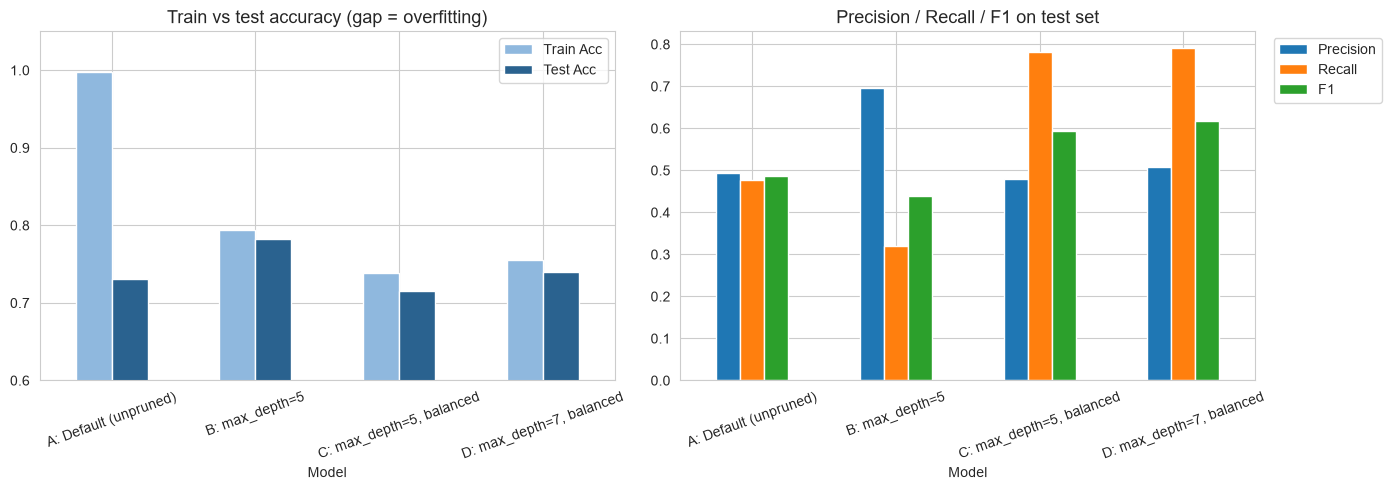

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

comparison[['Train Acc', 'Test Acc']].plot(kind='bar', ax=ax[0], rot=20,
                                            color=['#8FB8DE', '#2A628F'])
ax[0].set_title('Train vs test accuracy (gap = overfitting)')
ax[0].set_ylim(0.6, 1.05)

comparison[['Precision', 'Recall', 'F1']].plot(kind='bar', ax=ax[1], rot=20)
ax[1].set_title('Precision / Recall / F1 on test set')
ax[1].legend(bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

In [31]:
final_model = fitted['D: max_depth=7, balanced']
print(final_model.named_steps['classifier'])

DecisionTreeClassifier(class_weight='balanced', max_depth=7,
                       min_samples_leaf=30, random_state=42)


Model comparison:

- **A — Default tree:** 99.8% train vs 73.1% test accuracy; 27-point gap and 1,921 nodes → clear overfitting.
- **B — Depth 5:** best test accuracy at 78.2%, but recall is only 31.9%, so it misses most churners.
- **C — Depth 5 + balanced:** recall improves to 78.1%, but F1 is 0.593.
- **D — Depth 7 + balanced + `min_samples_leaf=30`:** recall 79.1%, F1 0.618, with only a 1.5-point train/test gap.

**Selected model: D.** The problem is focused on catching churners, so recall matters more than maximising accuracy. F1 also shows the higher recall is not coming from simply flagging everyone. The final tree has 113 nodes and remains easy to inspect.

## 5. Model Evaluation

In [32]:
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, ConfusionMatrixDisplay)

y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_proba), 4))
print()
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn'], digits=3))

Accuracy : 0.7402
Precision: 0.5068
Recall   : 0.7914
F1 Score : 0.618
ROC-AUC  : 0.8265

              precision    recall  f1-score   support

    No Churn      0.905     0.722     0.803      1552
       Churn      0.507     0.791     0.618       561

    accuracy                          0.740      2113
   macro avg      0.706     0.757     0.711      2113
weighted avg      0.800     0.740     0.754      2113



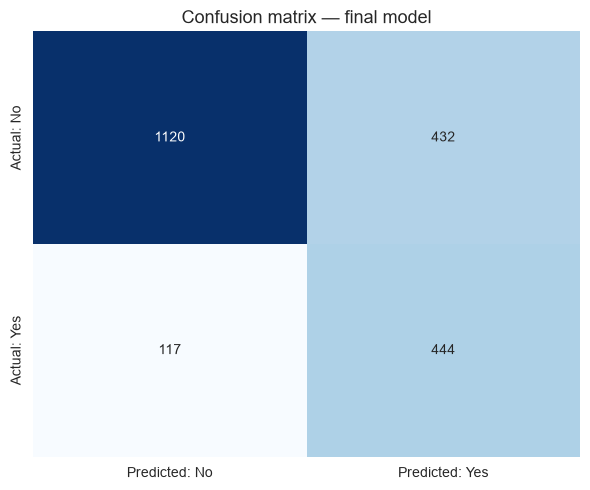

True Negatives : 1120  (correctly left alone)
False Positives: 432  (contacted unnecessarily)
False Negatives: 117  (churners we missed)
True Positives : 444  (churners we caught)


In [33]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted: No', 'Predicted: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'], ax=ax)
ax.set_title('Confusion matrix — final model')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives : {tn}  (correctly left alone)")
print(f"False Positives: {fp}  (contacted unnecessarily)")
print(f"False Negatives: {fn}  (churners we missed)")
print(f"True Positives : {tp}  (churners we caught)")

On 2,113 test customers, 561 actually churned. The model caught 444 and missed 117.

It flagged 432 non-churners as well, so 876 customers would be sent to the retention team. That is a 59% reduction from contacting everyone while still catching 79% of churners.

The business value depends on intervention cost and customer lifetime value. For example, at ₹500 per offer and ₹15,000 lifetime value, 432 unnecessary offers cost ₹2.16 lakh, while 444 retained customers represent up to ₹66 lakh in value if every intervention succeeds.

ROC-AUC is 0.8265, so the predicted probabilities also give a useful ranking for prioritising the retention list.

### Precision vs Recall

For this use case, recall is the main priority: missing a churner can mean losing the customer, while a false positive mainly costs the retention action.

That explains why Model B was not selected despite 78.2% accuracy. Its recall was only 31.9%, compared with 79.1% for the final model.

The trade-off is real: precision is 50.7%, so many flagged customers will stay anyway. The decision threshold can be adjusted later using `predict_proba`: a higher threshold gives a smaller, higher-confidence list; a lower threshold gives wider coverage.

## 6. Model Interpretation

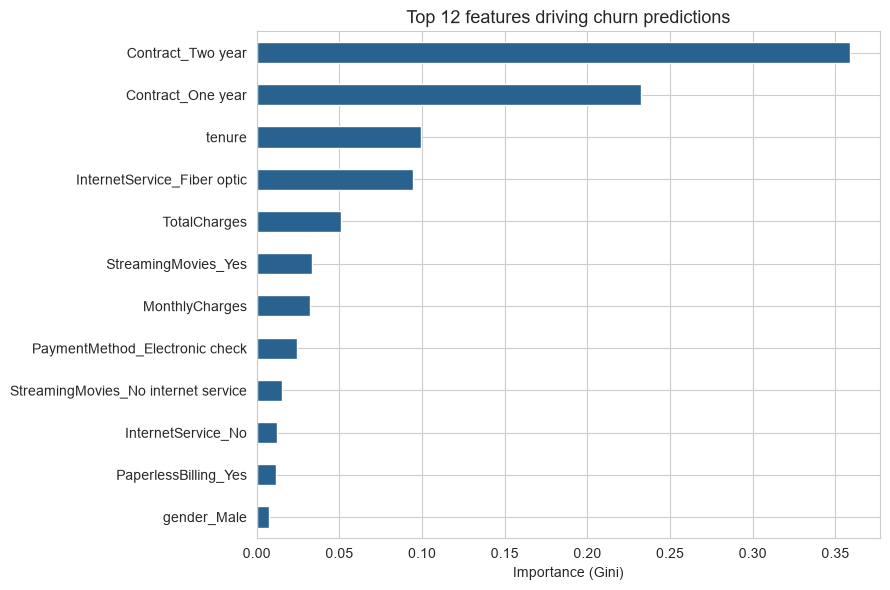

Contract_Two year                      0.3590
Contract_One year                      0.2325
tenure                                 0.0996
InternetService_Fiber optic            0.0943
TotalCharges                           0.0513
StreamingMovies_Yes                    0.0336
MonthlyCharges                         0.0323
PaymentMethod_Electronic check         0.0245
StreamingMovies_No internet service    0.0153
InternetService_No                     0.0124
PaperlessBilling_Yes                   0.0118
gender_Male                            0.0072
OnlineSecurity_Yes                     0.0069
TechSupport_Yes                        0.0066
MultipleLines_Yes                      0.0045
Partner_Yes                            0.0033
NumAddOnServices                       0.0030
OnlineBackup_Yes                       0.0010
SeniorCitizen                          0.0009

Features actually used: 19 of 36


In [34]:
feature_names = [n.split('__', 1)[1] for n in
                 final_model.named_steps['preprocessor'].get_feature_names_out()]

importances = pd.Series(
    final_model.named_steps['classifier'].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

top = importances.head(12)

fig, ax = plt.subplots(figsize=(9, 6))
top.sort_values().plot(kind='barh', color='#2A628F', ax=ax)
ax.set_title('Top 12 features driving churn predictions')
ax.set_xlabel('Importance (Gini)')
plt.tight_layout()
plt.show()

print(importances[importances > 0].round(4).to_string())
print(f"\nFeatures actually used: {(importances > 0).sum()} of {len(importances)}")

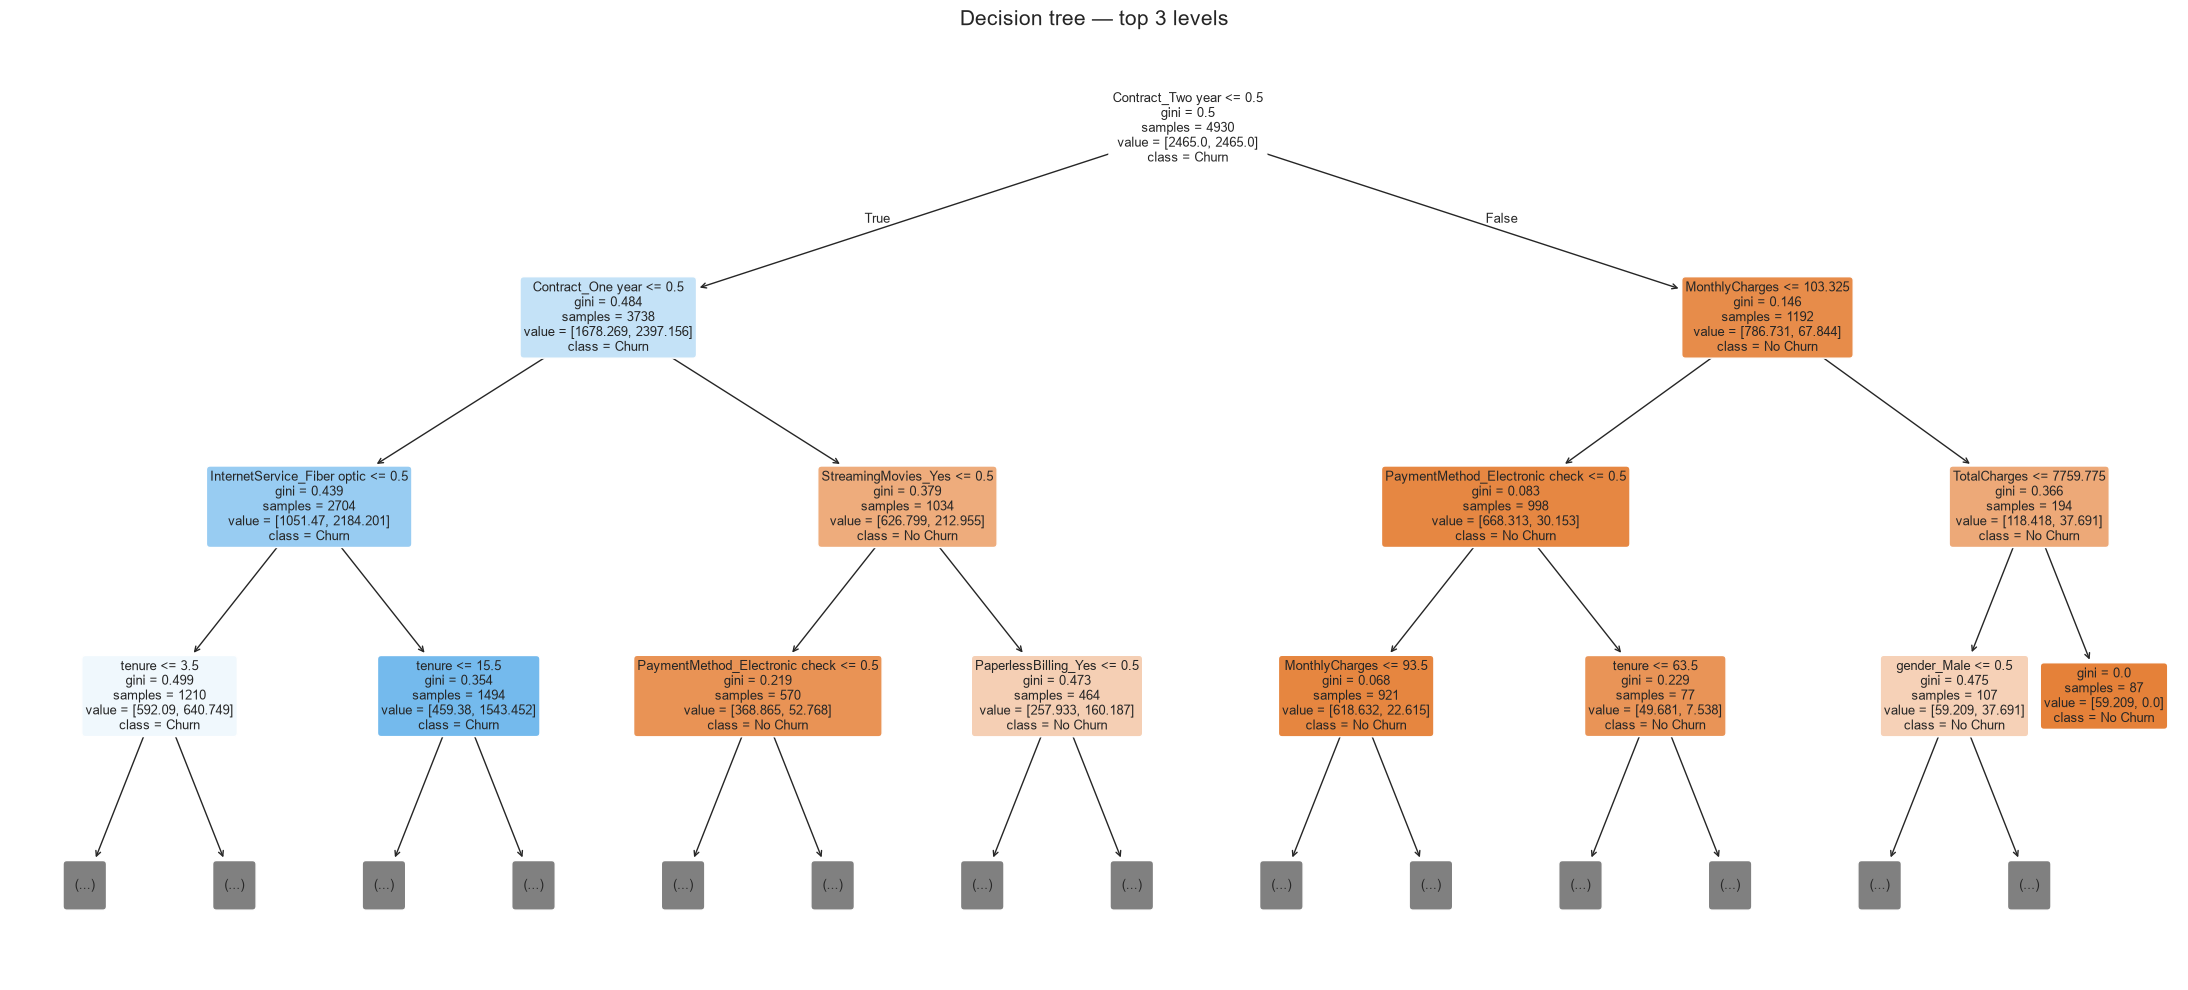

In [35]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(final_model.named_steps['classifier'],
          feature_names=feature_names,
          class_names=['No Churn', 'Churn'],
          max_depth=3, filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title('Decision tree — top 3 levels', fontsize=15)
plt.tight_layout()
plt.savefig('../model/decision_tree.png', dpi=110, bbox_inches='tight')
plt.show()

In [36]:
from sklearn.tree import export_text

print(export_text(final_model.named_steps['classifier'],
                  feature_names=feature_names, max_depth=3))

|--- Contract_Two year <= 0.50
|   |--- Contract_One year <= 0.50
|   |   |--- InternetService_Fiber optic <= 0.50
|   |   |   |--- tenure <= 3.50
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- tenure >  3.50
|   |   |   |   |--- truncated branch of depth 4
|   |   |--- InternetService_Fiber optic >  0.50
|   |   |   |--- tenure <= 15.50
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- tenure >  15.50
|   |   |   |   |--- truncated branch of depth 4
|   |--- Contract_One year >  0.50
|   |   |--- StreamingMovies_Yes <= 0.50
|   |   |   |--- PaymentMethod_Electronic check <= 0.50
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- PaymentMethod_Electronic check >  0.50
|   |   |   |   |--- truncated branch of depth 3
|   |   |--- StreamingMovies_Yes >  0.50
|   |   |   |--- PaperlessBilling_Yes <= 0.50
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- PaperlessBilling_Yes >  0.50
|   |   |   |   |--- truncated branch of d

The main model signals are:

- Contract type: 59.2% combined importance (`Two year` 35.9%, `One year` 23.3%).
- Tenure: 10.0%.
- Fiber optic internet: 9.4%.
- Total charges: 5.1%.
- Electronic check: 2.5%.

The top tree path shows higher risk for customers not on long contracts, using fiber, and with shorter tenure.

Only 19 of 36 encoded features are used. The engineered features add little model importance: `NumAddOnServices` is 0.003, while `TenureBucket`, `HasAutoPayment` and `NewHighValue` are not used. They are largely redundant because the tree can learn the same patterns directly from the original variables.

The fiber result is worth a business follow-up because churn is high in this segment. The notebook does not establish whether pricing, service quality or another factor is responsible.

## 7. Model Saving

The full preprocessing + model pipeline is saved as `churn_model.pkl`, so `app.py` can load it without rebuilding the transformations.

In [37]:
import joblib, sklearn, json
from datetime import datetime

joblib.dump(final_model, '../model/churn_model.pkl')

metadata = {
    'model_type': 'DecisionTreeClassifier',
    'params': {'max_depth': 7, 'min_samples_leaf': 30, 'class_weight': 'balanced'},
    'sklearn_version': sklearn.__version__,
    'trained_on': datetime.now().strftime('%Y-%m-%d'),
    'numerical_features': numerical,
    'categorical_features': categorical,
    'metrics': {
        'accuracy': round(accuracy_score(y_test, y_pred), 4),
        'precision': round(precision_score(y_test, y_pred), 4),
        'recall': round(recall_score(y_test, y_pred), 4),
        'f1': round(f1_score(y_test, y_pred), 4),
        'roc_auc': round(roc_auc_score(y_test, y_proba), 4),
    }
}

with open('../model/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Saved. sklearn version:", sklearn.__version__)

Saved. sklearn version: 1.9.0


In [38]:
loaded = joblib.load('../model/churn_model.pkl')

sample = X_test.iloc[[0]]
print("Prediction:", loaded.predict(sample)[0])
print("Probability:", round(loaded.predict_proba(sample)[0][1], 4))
print("Actual:", y_test.iloc[0])
print("Matches original model:",
      (loaded.predict(X_test) == final_model.predict(X_test)).all())

Prediction: 1
Probability: 0.6282
Actual: 1
Matches original model: True


## 8. Additional Work

Two extra checks are included beyond the required workflow:

1. Grid-search hyperparameter tuning with stratified cross-validation.
2. Comparison with Logistic Regression and Random Forest.

In [39]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'classifier__max_depth': [4, 5, 6, 7, 8, 10],
    'classifier__min_samples_leaf': [10, 20, 30, 50],
    'classifier__criterion': ['gini', 'entropy'],
}

search_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(class_weight='balanced', random_state=42))
])

grid = GridSearchCV(
    search_pipe,
    param_grid,
    scoring='f1',
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    n_jobs=-1
)
grid.fit(X_train, y_train)

print("Combinations tested:", len(grid.cv_results_['params']))
print("Best params:", grid.best_params_)
print("Best CV F1 :", round(grid.best_score_, 4))

tuned_pred = grid.best_estimator_.predict(X_test)
print("\nTuned model on test set:")
print("  F1     :", round(f1_score(y_test, tuned_pred), 4))
print("  Recall :", round(recall_score(y_test, tuned_pred), 4))
print("\nManually selected model on test set:")
print("  F1     :", round(f1_score(y_test, y_pred), 4))
print("  Recall :", round(recall_score(y_test, y_pred), 4))

Combinations tested: 48
Best params: {'classifier__criterion': 'entropy', 'classifier__max_depth': 7, 'classifier__min_samples_leaf': 50}
Best CV F1 : 0.6186

Tuned model on test set:
  F1     : 0.6031
  Recall : 0.7326

Manually selected model on test set:
  F1     : 0.618
  Recall : 0.7914


### Hyperparameter tuning

48 parameter combinations were tested with 5-fold stratified cross-validation using F1.

Best CV configuration: `entropy`, `max_depth=7`, `min_samples_leaf=50`, with CV F1 = 0.6186.

On the held-out test set, it reached F1 = 0.6031 and recall = 0.7326, below the manually selected model (F1 = 0.618, recall = 0.7914). The manual configuration therefore remains the final model.

The result also shows why the best CV score does not always transfer directly to the unseen test set.

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

scaled_pre = ColumnTransformer([
    ('num', StandardScaler(), numerical),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical)
])

candidates = {
    'Logistic Regression': Pipeline([
        ('preprocessor', scaled_pre),
        ('classifier', LogisticRegression(max_iter=2000, class_weight='balanced',
                                          random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=300, max_depth=12,
                                              min_samples_leaf=10,
                                              class_weight='balanced',
                                              random_state=42, n_jobs=-1))
    ]),
}


def score_model(name, pipe):
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    return {'Model': name,
            'Accuracy': accuracy_score(y_test, pred),
            'Precision': precision_score(y_test, pred),
            'Recall': recall_score(y_test, pred),
            'F1': f1_score(y_test, pred),
            'ROC-AUC': roc_auc_score(y_test, proba)}


rows = [score_model('Decision Tree (final)', final_model)]

for name, pipe in candidates.items():
    pipe.fit(X_train, y_train)
    rows.append(score_model(name, pipe))

pd.DataFrame(rows).set_index('Model').round(3)

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Decision Tree (final),0.740,0.507,0.791,0.618,0.826
Logistic Regression,0.741,0.508,0.795,0.620,0.844
Random Forest,0.763,0.537,0.788,0.639,0.843


### Comparison with other algorithms

Logistic Regression uses `StandardScaler` because feature magnitude affects it; trees and forests do not need scaling.

Test results:

- Decision Tree: accuracy 0.740, F1 0.618, ROC-AUC 0.826
- Logistic Regression: accuracy 0.741, F1 0.620, ROC-AUC 0.844
- Random Forest: accuracy 0.763, F1 0.639, ROC-AUC 0.843

Random Forest has the highest F1, while Logistic Regression has the highest ROC-AUC. The Decision Tree is retained because the brief calls for one model and its rules are easier for a retention team to inspect and explain.

The pipeline is structured so another classifier can be swapped in later if predictive performance becomes the priority.

### Summary

The notebook covers the full churn workflow: data preparation, EDA, feature engineering, model development, evaluation, interpretation, model saving and API serving.

Final model: Decision Tree with `max_depth=7`, `min_samples_leaf=30`, and `class_weight='balanced'`.

Test performance: recall 0.791, F1 0.618, ROC-AUC 0.8265; 444 of 561 churners were caught while reducing the contact list by 59%.

The strongest model signals are contract type, short tenure and fiber optic internet.